# EEGPT: Pretrained Transformer for EEG

论文链接：[EEGPT: Pretrained Transformer for EEG](https://proceedings.neurips.cc/paper_files/paper/2024/hash/4540d267eeec4e5dbd9dae9448f0b739-Abstract-Conference.html)

## Methods

EEGPT 属于 mask-based dual self-supervised learning，同时优化“重建”和“表征对齐”。对 EEG patch 序列 $X$，随机选择遮挡集合 $\mathcal{M}$，得到遮挡输入 $\tilde{X}$。完整分支和遮挡分支分别产生：
$$H=F_\theta(X),\qquad \tilde{H}=F_\theta(\tilde{X}).$$

第一项是 masked reconstruction，对被遮挡 patch 做波形或局部特征恢复：
$$\mathcal{L}_{rec}=\sum_{i\in\mathcal{M}}\left\|D_\psi(\tilde{H}_i)-X_i\right\|_2^2.$$
第二项是 spatio-temporal representation alignment，让遮挡输入得到的表示靠近完整输入的高信噪比表示：
$$\mathcal{L}_{align}=\sum_{i\in\mathcal{M}}\left(1-\cos\left(P_\omega(\tilde{H}_i),\mathrm{sg}[H_i]\right)\right),$$
总损失为：
$$\mathcal{L}=\mathcal{L}_{rec}+\lambda\mathcal{L}_{align}.$$

结构上，EEGPT 使用分层时空建模。局部空间模块先在每个时间 patch 内混合通道信息，时间模块再建模 patch 之间的动态变化。每个 Transformer block 的注意力可写成：
$$\mathrm{Attn}(Q,K,V)=\mathrm{softmax}\left(\frac{QK^\top}{\sqrt{d}}\right)V.$$
通过把空间维和时间维拆开处理，模型降低了全局时空注意力的复杂度，也更容易适配不同采样设备和通道布局。下游任务一般冻结或微调预训练骨干，并使用线性探测/轻量分类头：
$$\hat{y}=\mathrm{softmax}(W\,\mathrm{pool}(H)+b).$$

## Tiny 版

原论文均使用大规模 EEG 语料和较大的 Transformer 进行预训练。为了在普通 CPU 环境中直接运行，下面实现的是论文的轻量版预训练：先在 `data/go2_eeg_preprocessed.npz` 上构造自监督预训练任务，再用同一个骨干网络微调三分类头。

In [1]:
from pathlib import Path
import math
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


def find_project_root(start=Path.cwd()):
    start = Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / "data" / "go2_eeg_preprocessed.npz").exists():
            return path
    raise FileNotFoundError("Cannot find data/go2_eeg_preprocessed.npz from current path.")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "go2_eeg_preprocessed.npz"
print("project root:", PROJECT_ROOT)

device: cuda
project root: C:\Users\zxzhang\Desktop\智能脑机接口\实验


In [2]:
data = np.load(DATA_PATH, allow_pickle=True)
X_train = data["X_train"].astype("float32")
X_test = data["X_test"].astype("float32")
y_train = data["y_train"].astype("int64")
y_test = data["y_test"].astype("int64")
label_classes = data["label_classes"].astype(str).tolist()
sfreq = int(data["target_sfreq"])

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("classes:", dict(enumerate(label_classes)), "sfreq:", sfreq)

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=32,
    shuffle=True,
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test), torch.tensor(y_test)),
    batch_size=64,
    shuffle=False,
)

X_train: (141, 8, 1248) X_test: (36, 8, 1248)
classes: {0: 'L', 1: 'R', 2: 'S'} sfreq: 250


In [3]:
def patchify(x, patch_len=64):
    """Return channel-time patches with shape (B, C, P, patch_len)."""
    b, c, t = x.shape
    n_patches = t // patch_len
    x = x[..., : n_patches * patch_len]
    return x.reshape(b, c, n_patches, patch_len)


def make_mask(batch, channels, patches, mask_ratio=0.35, contiguous=False):
    mask = torch.zeros(batch, channels, patches, dtype=torch.bool)
    if contiguous:
        span_t = max(1, int(round(patches * mask_ratio)))
        span_c = max(1, int(round(channels * 0.4)))
        for i in range(batch):
            t0 = torch.randint(0, patches - span_t + 1, (1,)).item()
            c0 = torch.randint(0, channels - span_c + 1, (1,)).item()
            mask[i, c0 : c0 + span_c, t0 : t0 + span_t] = True
    else:
        mask = torch.rand(batch, channels, patches) < mask_ratio
        empty = ~mask.flatten(1).any(dim=1)
        if empty.any():
            mask[empty, 0, 0] = True
    return mask


def run_classifier(model, train_loader, test_loader, epochs=25, lr=1e-3):
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    history = {"loss": [], "train_acc": [], "test_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        pred_all, true_all = [], []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            losses.append(loss.item())
            pred_all.extend(logits.argmax(1).detach().cpu().numpy())
            true_all.extend(yb.cpu().numpy())

        test_pred, test_true, _ = predict(model, test_loader)
        history["loss"].append(float(np.mean(losses)))
        history["train_acc"].append(accuracy_score(true_all, pred_all))
        history["test_acc"].append(accuracy_score(test_true, test_pred))
        if epoch in {1, epochs} or epoch % 5 == 0:
            print(
                f"epoch {epoch:02d} | loss={history['loss'][-1]:.4f} "
                f"| train_acc={history['train_acc'][-1]:.3f} | test_acc={history['test_acc'][-1]:.3f}"
            )
    return history


@torch.no_grad()
def predict(model, loader):
    model.eval()
    pred_all, true_all, prob_all = [], [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        prob = logits.softmax(dim=1).cpu().numpy()
        prob_all.append(prob)
        pred_all.extend(prob.argmax(axis=1))
        true_all.extend(yb.numpy())
    return np.array(pred_all), np.array(true_all), np.vstack(prob_all)


def plot_results(history, y_true, y_pred, labels, title):
    from IPython.display import display

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history["train_acc"], label="train")
    axes[0].plot(history["test_acc"], label="test")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title(title)
    axes[0].legend()

    class_ids = np.arange(len(labels))
    cm = confusion_matrix(y_true, y_pred, labels=class_ids)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=axes[1], cmap="Blues", colorbar=False)
    axes[1].set_title("Test confusion matrix")
    plt.tight_layout()

    output_dir = PROJECT_ROOT / "tutorials" / "Foundation Model" / "outputs"
    output_dir.mkdir(parents=True, exist_ok=True)
    safe_name = title.lower().replace(" ", "_").replace("/", "_")
    output_path = output_dir / f"{safe_name}_confusion.png"
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    display(fig)
    plt.show()
    print("saved figure:", output_path)
    return fig

下面实现一个分层 Transformer：空间模块在每个时间 patch 内混合通道信息，时间模块处理 patch 序列；预训练损失由 masked waveform reconstruction 和表示对齐两部分组成。

In [4]:
class TinyEEGPT(nn.Module):
    def __init__(self, channels, n_patches, patch_len=64, d_model=64, heads=4):
        super().__init__()
        self.channels = channels
        self.n_patches = n_patches
        self.patch_len = patch_len
        self.patch_proj = nn.Linear(patch_len, d_model)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, 1, d_model))
        self.local_embed = nn.Parameter(torch.randn(channels, n_patches, d_model) * 0.02)
        spatial_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=heads, dim_feedforward=128, dropout=0.1, batch_first=True
        )
        temporal_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=heads, dim_feedforward=128, dropout=0.1, batch_first=True
        )
        self.spatial = nn.TransformerEncoder(spatial_layer, num_layers=1)
        self.temporal = nn.TransformerEncoder(temporal_layer, num_layers=2)
        self.align_head = nn.Linear(d_model, d_model)
        self.recon_head = nn.Linear(d_model, patch_len)
        self.norm = nn.LayerNorm(d_model)

    def encode_tokens(self, x, mask=None):
        patches = patchify(x, self.patch_len)
        z = self.patch_proj(patches)
        if mask is not None:
            z = torch.where(mask[..., None], self.mask_token.to(z.dtype), z)
        z = z + self.local_embed[None, :, :, :]
        b, c, p, d = z.shape
        spatial_in = z.permute(0, 2, 1, 3).reshape(b * p, c, d)
        spatial_out = self.spatial(spatial_in).reshape(b, p, c, d).permute(0, 2, 1, 3)
        temporal_in = spatial_out.mean(dim=1)
        temporal_out = self.temporal(temporal_in)
        fused = spatial_out + temporal_out[:, None, :, :]
        return self.norm(fused)

    def forward_features(self, x):
        return self.encode_tokens(x).mean(dim=(1, 2))

    def pretrain_forward(self, x, mask):
        z_masked = self.encode_tokens(x, mask=mask)
        with torch.no_grad():
            z_full = self.encode_tokens(x, mask=None)
        recon = self.recon_head(z_masked)
        aligned = self.align_head(z_masked)
        return recon, aligned, z_full


class EEGPTClassifier(nn.Module):
    def __init__(self, backbone, n_classes):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(nn.LayerNorm(64), nn.Linear(64, n_classes))

    def forward(self, x):
        return self.head(self.backbone.forward_features(x))

pretrain epoch 01 | dual SSL loss=1.1996
pretrain epoch 02 | dual SSL loss=0.8972
pretrain epoch 03 | dual SSL loss=0.7532
pretrain epoch 04 | dual SSL loss=0.7079
pretrain epoch 05 | dual SSL loss=0.6356
epoch 01 | loss=1.1694 | train_acc=0.319 | test_acc=0.306
epoch 05 | loss=1.0283 | train_acc=0.454 | test_acc=0.167
epoch 10 | loss=0.8944 | train_acc=0.603 | test_acc=0.194
epoch 15 | loss=0.7651 | train_acc=0.674 | test_acc=0.222
epoch 20 | loss=0.4662 | train_acc=0.830 | test_acc=0.194
epoch 25 | loss=0.1181 | train_acc=0.986 | test_acc=0.250
              precision    recall  f1-score   support

           L       0.20      0.17      0.18        12
           R       0.08      0.08      0.08        12
           S       0.43      0.50      0.46        12

    accuracy                           0.25        36
   macro avg       0.24      0.25      0.24        36
weighted avg       0.24      0.25      0.24        36



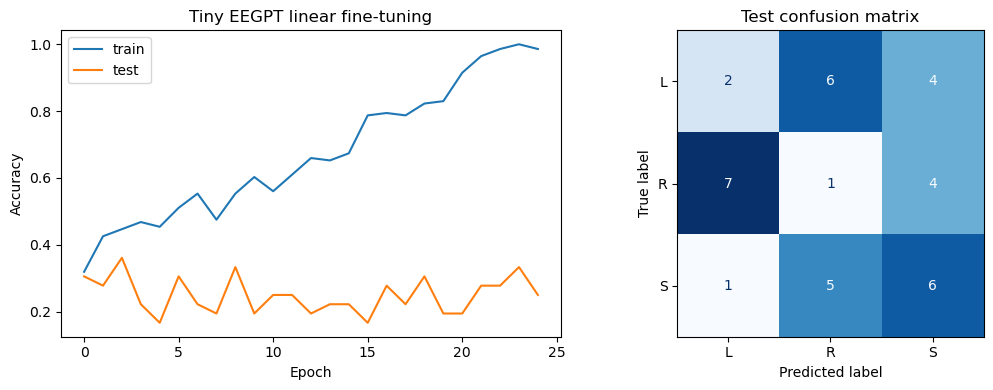

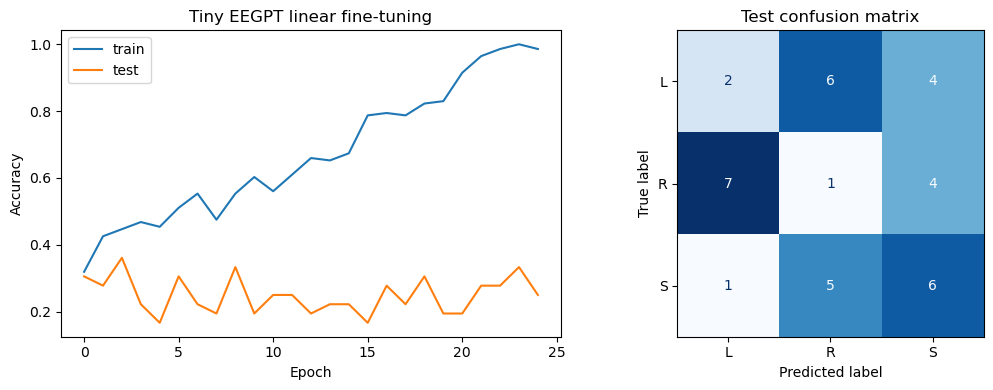

saved figure: C:\Users\zxzhang\Desktop\智能脑机接口\实验\tutorials\Foundation Model\outputs\tiny_eegpt_linear_fine-tuning_confusion.png


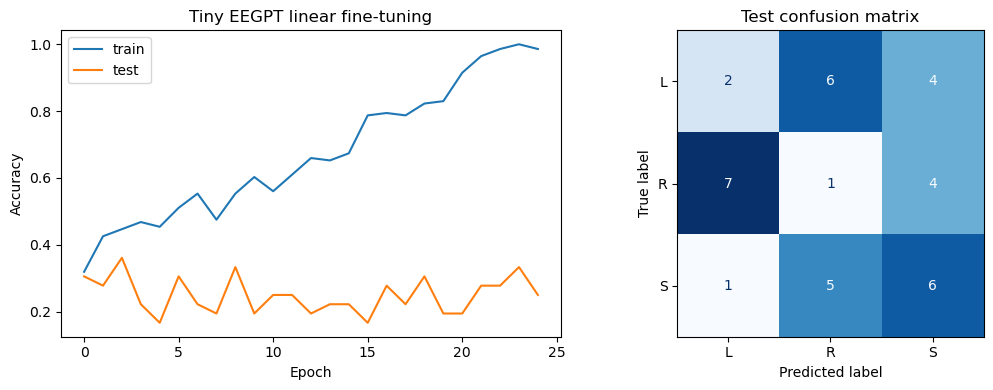

In [5]:
patch_len = 64
channels = X_train.shape[1]
n_patches = X_train.shape[2] // patch_len
n_classes = len(label_classes)

backbone = TinyEEGPT(channels, n_patches, patch_len=patch_len).to(device)
opt = torch.optim.AdamW(backbone.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(1, 6):
    backbone.train()
    losses = []
    for xb, _ in train_loader:
        xb = xb.to(device)
        patches = patchify(xb, patch_len).to(device)
        mask = make_mask(len(xb), channels, n_patches, mask_ratio=0.35).to(device)
        recon, aligned, full = backbone.pretrain_forward(xb, mask)
        recon_loss = F.mse_loss(recon[mask], patches[mask])
        align_loss = 1 - F.cosine_similarity(aligned[mask], full[mask].detach(), dim=-1).mean()
        loss = recon_loss + 0.1 * align_loss
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
    print(f"pretrain epoch {epoch:02d} | dual SSL loss={np.mean(losses):.4f}")

classifier = EEGPTClassifier(backbone, n_classes)
history = run_classifier(classifier, train_loader, test_loader, epochs=25, lr=8e-4)
y_pred, y_true, y_prob = predict(classifier, test_loader)
print(classification_report(y_true, y_pred, target_names=label_classes, zero_division=0))
plot_results(history, y_true, y_pred, label_classes, "Tiny EEGPT linear fine-tuning")

## GPU 版

下载 EEGPT 的仓库到 `tutorials/Foundation Model/official_code/EEGPT`。官方 README 指向 Figshare private link `https://figshare.com/s/e37df4f8a907a866df4b`，要求将 `eegpt_mcae_58chs_4s_large4E.ckpt` 放到 `official_code/EEGPT/checkpoint/`。

In [6]:
from pathlib import Path
import sys

RUN_OFFICIAL_GPU = True  # 是否运行官方大模型微调
OFFICIAL_ROOT = PROJECT_ROOT / "tutorials" / "Foundation Model" / "official_code"
print("official code root:", OFFICIAL_ROOT)
print("CUDA available:", torch.cuda.is_available())

official code root: C:\Users\zxzhang\Desktop\智能脑机接口\实验\tutorials\Foundation Model\official_code
CUDA available: True


Patched EEGPT Attention: using matmul attention because this torch lacks scaled_dot_product_attention.
loaded official EEGPT: 105 compatible tensors; 107 missing; 0 unexpected; 308 skipped
epoch 01 | loss=1.1158 | train_acc=0.305 | test_acc=0.361
epoch 05 | loss=0.9164 | train_acc=0.617 | test_acc=0.278
epoch 10 | loss=0.6636 | train_acc=0.780 | test_acc=0.278
epoch 15 | loss=0.4054 | train_acc=0.943 | test_acc=0.278
epoch 20 | loss=0.2401 | train_acc=0.979 | test_acc=0.361
epoch 25 | loss=0.0693 | train_acc=0.993 | test_acc=0.278
              precision    recall  f1-score   support

           L       0.25      0.25      0.25        12
           R       0.33      0.25      0.29        12
           S       0.27      0.33      0.30        12

    accuracy                           0.28        36
   macro avg       0.28      0.28      0.28        36
weighted avg       0.28      0.28      0.28        36



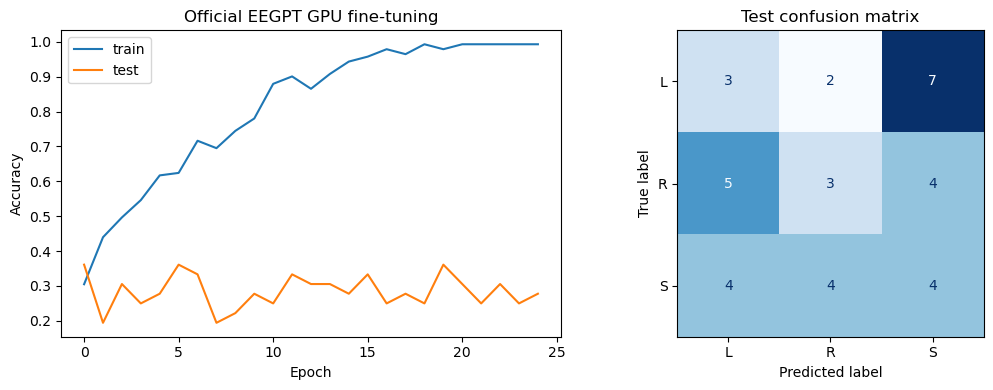

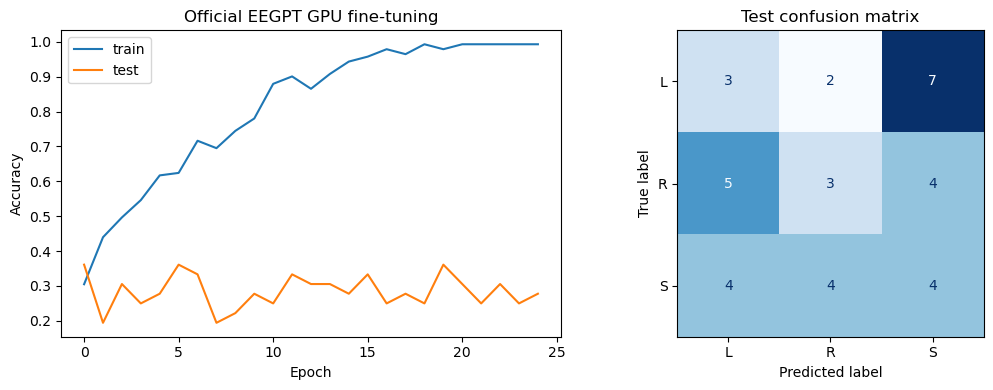

saved figure: C:\Users\zxzhang\Desktop\智能脑机接口\实验\tutorials\Foundation Model\outputs\official_eegpt_gpu_fine-tuning_confusion.png


In [7]:
if RUN_OFFICIAL_GPU:
    assert torch.cuda.is_available(), "官方 GPU 微调需要 CUDA。当前环境没有检测到 GPU。"
    eegpt_root = OFFICIAL_ROOT / "EEGPT"
    ckpt_path = eegpt_root / "checkpoint" / "eegpt_mcae_58chs_4s_large4E.ckpt"
    assert ckpt_path.exists() and ckpt_path.stat().st_size > 1024, (
        "缺少官方 EEGPT checkpoint。请从官方 Figshare 链接下载 "
        "eegpt_mcae_58chs_4s_large4E.ckpt 到 official_code/EEGPT/checkpoint/。"
    )
    sys.path.insert(0, str(eegpt_root / "downstream" / "Modules" / "models"))
    from EEGPT_mcae_finetune import EEGPTClassifier, CHANNEL_DICT, Conv1dWithConstraint, LinearWithConstraint, Attention

    # 官方代码在 Conv1dWithConstraint/LinearWithConstraint.forward 上使用 @autocast(True)。
    # 在部分 CUDA/PyTorch 组合中，这会把输入转成 float16，但权重仍保持 float32，触发
    # "Input type torch.cuda.HalfTensor and weight type torch.cuda.FloatTensor should be the same"。
    # 这里禁用这两个约束层内部的 autocast，保持官方模型用 float32 稳定微调。
    def _conv1d_forward_no_autocast(self, x):
        if self.doWeightNorm:
            self.weight.data = torch.renorm(
                self.weight.data, p=2, dim=0, maxnorm=self.max_norm
            )
        return nn.Conv1d.forward(self, x.float())

    def _linear_forward_no_autocast(self, x):
        if self.doWeightNorm:
            self.weight.data = torch.renorm(
                self.weight.data, p=2, dim=0, maxnorm=self.max_norm
            )
        return nn.Linear.forward(self, x.float())

    Conv1dWithConstraint.forward = _conv1d_forward_no_autocast
    LinearWithConstraint.forward = _linear_forward_no_autocast

    # PyTorch 1.x 没有 torch.nn.functional.scaled_dot_product_attention。
    # EEGPT 官方 Attention 默认调用 SDPA；这里在旧版 torch 中回退到标准 matmul attention。
    if not hasattr(F, "scaled_dot_product_attention"):
        def _attention_forward_no_sdpa(self, x, freqs=None):
            B, T, C = x.shape
            qkv = self.qkv(x).reshape(B, T, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
            q, k, v = qkv[0], qkv[1], qkv[2]

            if self.use_rope:
                from EEGPT_mcae_finetune import apply_rotary_emb
                q = apply_rotary_emb(freqs, q)
                k = apply_rotary_emb(freqs, k)

            attn = (q @ k.transpose(-2, -1)) / math.sqrt(q.size(-1))
            if self.is_causal:
                causal_mask = torch.ones(T, T, dtype=torch.bool, device=x.device).tril()
                attn = attn.masked_fill(~causal_mask, -torch.finfo(attn.dtype).max)
            attn = torch.softmax(attn, dim=-1)
            attn = F.dropout(attn, p=self.attn_drop, training=self.training)
            if self.return_attention:
                return attn

            y = attn @ v
            x = y.transpose(1, 2).contiguous().view(B, T, C)
            x = self.proj(x)
            return self.proj_drop(x)

        Attention.forward = _attention_forward_no_sdpa
        print("Patched EEGPT Attention: using matmul attention because this torch lacks scaled_dot_product_attention.")

    class OfficialEEGPTGo2(nn.Module):
        def __init__(self, n_classes):
            super().__init__()
            self.channel_names = ["FP1", "FP2", "C3", "C4", "P3", "P4", "O1", "O2"]
            self.model = EEGPTClassifier(
                num_classes=n_classes,
                in_channels=len(self.channel_names),
                img_size=[len(self.channel_names), 256 * 4],
                use_channels_names=self.channel_names,
                # 保持 8 通道输入，与 8 个 chan_ids 对齐；否则 use_chan_conv=True 会投影到 58 通道，
                # 但 chan_ids 仍为 8 个，触发 58 vs 8 的通道嵌入维度错误。
                use_chan_conv=False,
                desired_time_len=256 * 4,
                use_predictor=False,
            )
            chan_ids = torch.tensor([CHANNEL_DICT[name] for name in self.channel_names], dtype=torch.long)
            self.register_buffer("chan_ids", chan_ids)

            raw_state = torch.load(ckpt_path, map_location="cpu")
            state = raw_state.get("state_dict", raw_state.get("model", raw_state))
            cleaned = {}
            for k, v in state.items():
                for prefix in ("module.", "model.", "student.", "target_encoder."):
                    if k.startswith(prefix):
                        k = k[len(prefix):]
                # 官方 checkpoint 常是 encoder/reconstructor 预训练权重；分类头和通道卷积按本任务重新训练。
                cleaned[k] = v

            target_state = self.model.state_dict()
            compatible_state = {
                k: v for k, v in cleaned.items()
                if k in target_state and tuple(v.shape) == tuple(target_state[k].shape)
            }
            missing, unexpected = self.model.load_state_dict(compatible_state, strict=False)
            print(
                "loaded official EEGPT:",
                len(compatible_state), "compatible tensors;",
                len(missing), "missing;",
                len(unexpected), "unexpected;",
                len(cleaned) - len(compatible_state), "skipped"
            )

        def forward(self, x):
            x = x.float()
            x = F.interpolate(x, size=256 * 4, mode="linear", align_corners=False)
            return self.model(x, chan_ids=self.chan_ids)

    official_model = OfficialEEGPTGo2(len(label_classes))
    official_history = run_classifier(official_model, train_loader, test_loader, epochs=25, lr=1e-5)
    official_pred, official_true, _ = predict(official_model, test_loader)
    print(classification_report(official_true, official_pred, target_names=label_classes, zero_division=0))
    plot_results(official_history, official_true, official_pred, label_classes, "Official EEGPT GPU fine-tuning")
else:
    print("官方 EEGPT GPU 微调已跳过。下载 checkpoint、确认 CUDA 后，将 RUN_OFFICIAL_GPU 改为 True。")

In [8]:
final_acc = accuracy_score(y_true, y_pred)
chance = 1 / len(label_classes)
print(f"Final test accuracy: {final_acc:.3f} | chance level: {chance:.3f}")

class_counts = {label: int((y_true == i).sum()) for i, label in enumerate(label_classes)}
print("Test class counts:", class_counts)

if final_acc <= chance + 0.05:
    print("分析：当前小样本 demo 的结果接近随机水平，说明预训练轮数、数据规模或标签信噪比仍不足。")
elif history["train_acc"][-1] - history["test_acc"][-1] > 0.25:
    print("分析：训练集明显高于测试集，存在过拟合。可以减少模型宽度、增加正则化或使用更多被试/会话。")
else:
    print("分析：测试准确率高于随机水平，说明预训练得到的时空表征对 L/R/S 三类解码有一定帮助。")

Final test accuracy: 0.250 | chance level: 0.333
Test class counts: {'L': 12, 'R': 12, 'S': 12}
分析：当前小样本 demo 的结果接近随机水平，说明预训练轮数、数据规模或标签信噪比仍不足。
